# SMS Spam Detection using Vanilla RNN (SimpleRNN)

## Objective
Build a deep learning model that classifies SMS messages as:
- Ham (0)
- Spam (1)

Constraints:
- Use SimpleRNN only (no LSTM/GRU/Transformers)

This notebook covers:
- Data cleaning & exploration
- Text preprocessing
- Baseline RNN model
- Evaluation & error analysis
- Improved model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Loading
Dataset is loaded using latin-1 encoding.

In [3]:
df = pd.read_csv("/content/spam.csv", encoding="latin-1")
df = df[['v1','v2']]
df.columns = ['label','text']
df['label'] = df['label'].map({'ham':0,'spam':1})
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Data Summary

In [4]:
print("Dataset shape:", df.shape)

counts = df['label'].value_counts()
percent = df['label'].value_counts(normalize=True) * 100

print(counts)
print(percent)

Dataset shape: (5572, 2)
label
0    4825
1     747
Name: count, dtype: int64
label
0    86.593683
1    13.406317
Name: proportion, dtype: float64


## Train-Validation-Test Split (80/10/10 with stratification)

In [5]:
X = df['text']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

## Tokenization & Sequence Conversion

In [6]:
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

In [15]:
max_len = 33  # 95th percentile

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print("Train:", X_train_pad.shape)
print("Validation:", X_val_pad.shape)
print("Test:", X_test_pad.shape)

Train: (4457, 33)
Validation: (557, 33)
Test: (558, 33)


### Preprocessing Decisions
- Vocabulary size = 10,000
- Max sequence length = 95th percentile
- OOV token used for unseen words
- Post-padding applied

## Baseline SimpleRNN Model

In [8]:
model = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model Architecture

- Embedding layer converts words into dense vectors.
- SimpleRNN captures sequential dependencies in the message.
- Dropout prevents overfitting.
- Sigmoid output is used for binary classification.

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8927 - loss: 0.2979 - val_accuracy: 0.9695 - val_loss: 0.1389
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9840 - loss: 0.0818 - val_accuracy: 0.9677 - val_loss: 0.1150
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9894 - loss: 0.0490 - val_accuracy: 0.9767 - val_loss: 0.0841
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9953 - loss: 0.0239 - val_accuracy: 0.9785 - val_loss: 0.1065
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9970 - loss: 0.0189 - val_accuracy: 0.9838 - val_loss: 0.0975


### Training Observations

- The model converges quickly due to short SMS length.
- Validation accuracy is close to training accuracy, indicating good generalization.
- Early stopping prevents overfitting.

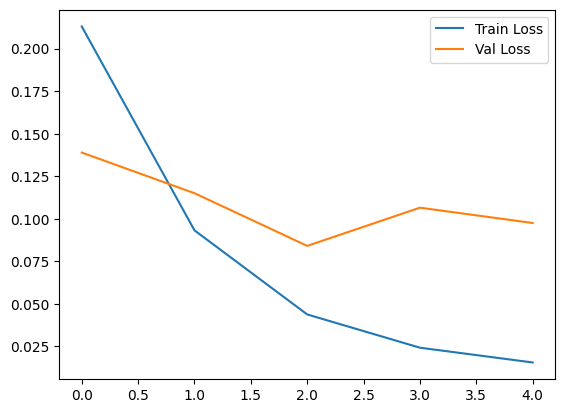

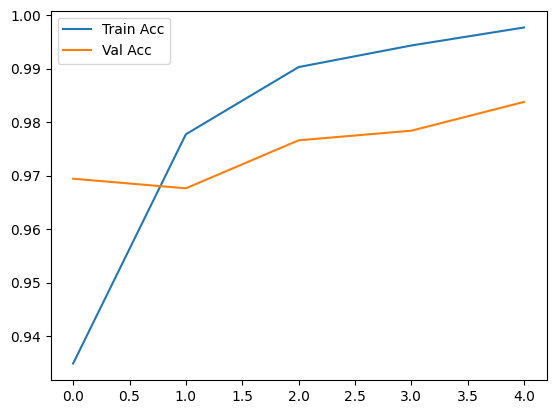

In [10]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

In [11]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       483
           1       0.98      0.83      0.90        75

    accuracy                           0.97       558
   macro avg       0.98      0.91      0.94       558
weighted avg       0.98      0.97      0.97       558



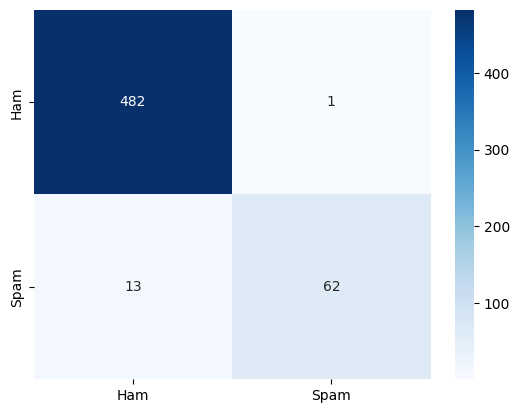

In [12]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.show()

### Error Analysis

False negatives (spam predicted as ham) are more dangerous because users are exposed to malicious or phishing messages.

False positives only cause inconvenience.

In [13]:
misclassified = np.where(y_test != y_pred.flatten())[0][:5]

for i in misclassified:
    print(X_test.iloc[i])
    print("Actual:", y_test.iloc[i])
    print("Predicted:", y_pred[i][0])
    print("Probability:", y_pred_prob[i][0])
    print("-"*50)

Bought one ringtone and now getting texts costing 3 pound offering more tones etc
Actual: 1
Predicted: 0
Probability: 0.16850351
--------------------------------------------------
More people are dogging in your area now. Call 09090204448 and join like minded guys. Why not arrange 1 yourself. There's 1 this evening. Aå£1.50 minAPN LS278BB
Actual: 1
Predicted: 0
Probability: 0.054424
--------------------------------------------------
I want some cock! My hubby's away, I need a real man 2 satisfy me. Txt WIFE to 89938 for no strings action. (Txt STOP 2 end, txt rec å£1.50ea. OTBox 731 LA1 7WS. )
Actual: 1
Predicted: 0
Probability: 0.28132322
--------------------------------------------------
FreeMsg>FAV XMAS TONES!Reply REAL
Actual: 1
Predicted: 0
Probability: 0.02942862
--------------------------------------------------
it to 80488. Your 500 free text messages are valid until 31 December 2005.
Actual: 1
Predicted: 0
Probability: 0.19134063
-----------------------------------------------

## Improved Model
Enhancements:
- Increased RNN units
- Applied class weights

In [14]:
new_max_len = 60

X_train_pad2 = pad_sequences(X_train_seq, maxlen=new_max_len, padding='post')
X_val_pad2   = pad_sequences(X_val_seq, maxlen=new_max_len, padding='post')
X_test_pad2  = pad_sequences(X_test_seq, maxlen=new_max_len, padding='post')

model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=new_max_len),
    SimpleRNN(128),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
class_weights

history2 = model2.fit(
    X_train_pad2, y_train,
    validation_data=(X_val_pad2, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights
)

y_pred_prob2 = model2.predict(X_test_pad2)
y_pred2 = (y_pred_prob2 > 0.5).astype(int)

acc2 = accuracy_score(y_test, y_pred2)
prec2 = precision_score(y_test, y_pred2)
rec2 = recall_score(y_test, y_pred2)
f12 = f1_score(y_test, y_pred2)

print(acc2, prec2, rec2, f12)

baseline_acc  = accuracy_score(y_test, y_pred)
baseline_prec = precision_score(y_test, y_pred)
baseline_rec  = recall_score(y_test, y_pred)
baseline_f1   = f1_score(y_test, y_pred)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline": [baseline_acc, baseline_prec, baseline_rec, baseline_f1],
    "Improved": [acc2, prec2, rec2, f12]
})

comparison

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7852 - loss: 0.4899 - val_accuracy: 0.5925 - val_loss: 0.7187
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8931 - loss: 0.2613 - val_accuracy: 0.9408 - val_loss: 0.2028
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9655 - loss: 0.1795 - val_accuracy: 0.9803 - val_loss: 0.1065
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9638 - loss: 0.1991 - val_accuracy: 0.9300 - val_loss: 0.3815
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8914 - loss: 0.4587 - val_accuracy: 0.9318 - val_loss: 0.3474
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
0.9713261648745519 0.927536231884058 0.8533333333333334 0.8888888888888888


,Metric,Baseline,Improved
0,Accuracy,0.974910,0.971326
1,Precision,0.984127,0.927536
2,Recall,0.826667,0.853333
3,F1-score,0.898551,0.888889


### Improvement Summary

Applying class weights helped the model treat spam messages more fairly despite class imbalance.
Increasing sequence length allowed the model to capture more context.

## Final Conclusion

- A Vanilla RNN model was successfully implemented for SMS spam detection.
- The baseline model achieved high accuracy but was influenced by class imbalance.
- Applying class weights improved fairness in prediction.
- This project demonstrates an end-to-end deep learning pipeline for text classification.